# F11: Contradiction tolerance — from inclusive to exclusive disjunction

The base model holds contradictions in superposition (Deleuze's inclusive disjunction: "or...or...or"). Alignment progressively imposes resolution (exclusive disjunction: "either/or"). Every pair moves upward through alignment stages.

**Data**: `data/contradiction_detail.csv` — precomputed via `scripts/contradiction_all.py`.  
**Figure**: `figures/F11_contradiction_biplot.png`

Superposition ratio = JS(combined, blend) / min(JS(combined, pole A), JS(combined, pole B))  
- Ratio < 1: combined prompt closer to the averaged blend → inclusive disjunction  
- Ratio > 1: combined prompt closer to one pole → exclusive disjunction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 1. Load data and summary

In [2]:
df = pd.read_csv('../data/contradiction_detail.csv')
df['pole_bias'] = df['js_to_A'] - df['js_to_B']

# Show all pairs × stages
pivot = df.pivot_table(index='pair', columns='model', values='ratio')
pivot = pivot[['base', 'sft', 'dpo', 'rlvr']]
pivot['crosses_1'] = (pivot[['sft', 'dpo', 'rlvr']] > 1.0).any(axis=1)
pivot.sort_values('dpo', ascending=False)

model,base,sft,dpo,rlvr,crosses_1
pair,,,,,
beautiful/disgusting,0.838439,1.094550,1.118681,1.127516,True
man/woman,0.957179,1.001534,1.060548,1.051732,True
free/captive,0.933095,1.018634,1.019505,1.049472,True
trust/fear,0.529497,0.858601,0.997842,0.959649,False
desire/disgust,0.776425,0.881235,0.947099,0.965634,False
pleasure/pain,0.352818,0.793924,0.942523,0.937119,False
create/destroy,0.621861,0.951080,0.926190,0.931898,False
love/hate,0.860469,0.906931,0.910228,0.911522,False
sacred/profane,0.488084,0.647553,0.804015,0.800975,False


## 2. Biplot: pole bias × superposition ratio

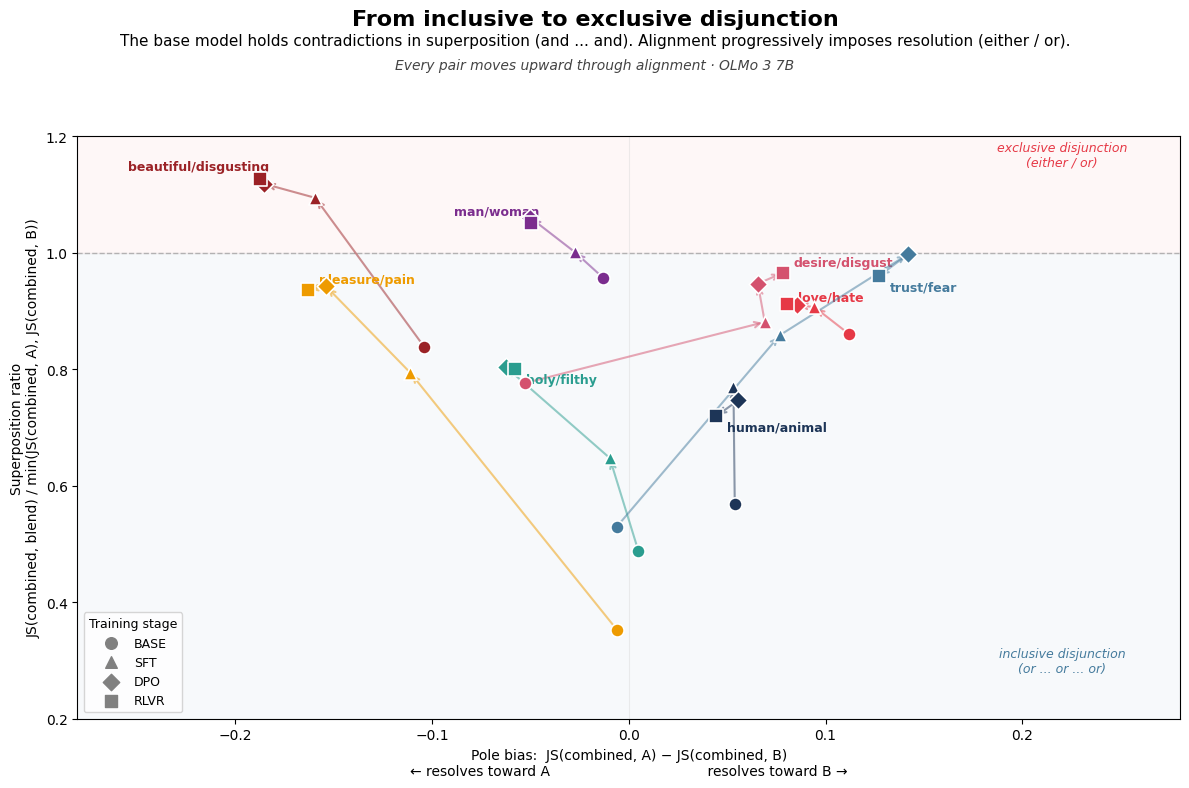

In [3]:
KEEP = ['love/hate', 'trust/fear', 'beautiful/disgusting', 'desire/disgust',
        'man/woman', 'human/animal', 'pleasure/pain']
RENAME = {'sacred/profane': 'holy/filthy'}
plot_df = df.copy()
plot_df['pair'] = plot_df['pair'].replace(RENAME)
# Also rename sacred/profane if present
plot_df = plot_df[plot_df['pair'].isin(KEEP + ['holy/filthy'])]

MODEL_ORDER = ['base', 'sft', 'dpo', 'rlvr']

COLORS = {
    'love/hate': '#e63946', 'trust/fear': '#457b9d', 'beautiful/disgusting': '#9b2226',
    'desire/disgust': '#d4526e', 'holy/filthy': '#2a9d8f',
    'man/woman': '#7b2d8e', 'human/animal': '#1d3557', 'pleasure/pain': '#ee9b00',
}
MODEL_MARKERS = {'base': 'o', 'sft': '^', 'dpo': 'D', 'rlvr': 's'}

fig, ax = plt.subplots(figsize=(12, 8))

ax.axhline(1.0, color='#999', linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(0.0, color='#ddd', linestyle='-', linewidth=0.8, alpha=0.5)
ax.fill_between([-0.3, 0.3], 1.0, 1.2, alpha=0.04, color='#e63946')
ax.fill_between([-0.3, 0.3], 0.2, 1.0, alpha=0.04, color='#457b9d')
ax.text(0.22, 1.15, 'exclusive disjunction\n(either / or)', fontsize=9, color='#e63946',
        style='italic', ha='center')
ax.text(0.22, 0.28, 'inclusive disjunction\n(or ... or ... or)', fontsize=9, color='#457b9d',
        style='italic', ha='center')

NUDGES = {
    'human/animal': (8, -10),
    'beautiful/disgusting': (-95, 6),
    'desire/disgust': (8, 5),
    'man/woman': (-55, 6),
    'love/hate': (8, 3),
    'trust/fear': (8, -10),
    'holy/filthy': (8, -10),
    'pleasure/pain': (8, 5),
}

for pair_name, grp in plot_df.groupby('pair'):
    grp = grp.set_index('model').loc[MODEL_ORDER]
    color = COLORS.get(pair_name, '#888')
    
    xs = grp['pole_bias'].values
    ys = grp['ratio'].values
    
    for i in range(len(xs) - 1):
        ax.annotate('', xy=(xs[i+1], ys[i+1]), xytext=(xs[i], ys[i]),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.5, alpha=0.5))
    
    for model, marker in MODEL_MARKERS.items():
        row = grp.loc[model]
        ax.scatter(row['pole_bias'], row['ratio'], color=color, s=90, marker=marker,
                   edgecolors='white', linewidth=1.2, zorder=5)
    
    nx, ny = NUDGES.get(pair_name, (8, 3))
    ax.annotate(pair_name, (xs[-1], ys[-1]), textcoords='offset points',
                xytext=(nx, ny), fontsize=9, color=color, fontweight='bold')

for model, marker in MODEL_MARKERS.items():
    ax.scatter([], [], color='gray', s=70, marker=marker, label=model.upper())
ax.legend(fontsize=9, loc='lower left', title='Training stage', title_fontsize=9)

ax.set_xlabel('Pole bias:  JS(combined, A) − JS(combined, B)\n'
              '← resolves toward A                                    resolves toward B →',
              fontsize=10)
ax.set_ylabel('Superposition ratio\nJS(combined, blend) / min(JS(combined, A), JS(combined, B))',
              fontsize=10)

fig.suptitle('From inclusive to exclusive disjunction',
             fontsize=16, fontweight='bold', y=0.98)
fig.text(0.5, 0.935,
         'The base model holds contradictions in superposition (and ... and). '
         'Alignment progressively imposes resolution (either / or).',
         ha='center', fontsize=11)
fig.text(0.5, 0.905,
         'Every pair moves upward through alignment · OLMo 3 7B',
         ha='center', fontsize=10, style='italic', color='#444444')

ax.set_xlim(-0.28, 0.28)
ax.set_ylim(0.2, 1.2)
plt.tight_layout(rect=[0, 0, 1, 0.89])
plt.savefig('../figures/F11_contradiction_biplot.png', dpi=200, bbox_inches='tight')
plt.show()